In [2]:
import matplotlib.pyplot as plt
import numpy as np
from qibo.gates import M, X, RY, CZ, I, H
from qibo.models import Circuit
from qiboconnection.api import API
import matplotlib.pyplot as plt

from qiboconnection.connection import ConnectionConfiguration

from benchmarks.utils.qst_qpt_helper_functions import process_returned_dataformat

from itertools import product
from scipy.stats import multivariate_normal
api = API(ConnectionConfiguration(username="apalacios", api_key="3ec51562-3ff2-4f7b-add8-b21e1645a89d"))
from scipy import stats

api.select_device_id(9)

In [3]:
def get_chsh_circuits(bell_state, control_qubit, target_qubit, theta):
    assert bell_state in (
        "phi_plus",
        "phi_minus",
        "psi_plus",
        "psi_minus",
    ), "bell_state should be phi_plus, phi_minus, psi_plus, psi_minus"
    nqubits = max(control_qubit, target_qubit) + 1

    circuits = []
    for gate_a, gate_b in product([I, H], repeat=2):
        circuit = Circuit(nqubits)

        if bell_state == "phi_plus" or bell_state == "psi_minus":
            G1 = RY(control_qubit, theta=-np.pi / 2)
        else:
            G1 = RY(control_qubit, theta=np.pi / 2)
        if bell_state == "phi_plus" or bell_state == "phi_minus":
            G2_prime = RY(target_qubit, theta=-np.pi / 2)
        else:
            G2_prime = RY(target_qubit, theta=np.pi / 2)
        ## build bell state
        circuit.add(G1)
        circuit.add(RY(target_qubit, theta=np.pi / 2))
        circuit.add(CZ(control_qubit, target_qubit))
        circuit.add(G2_prime)

        ## decoder part
        circuit.add(RY(control_qubit, theta=theta))
        circuit.add(gate_a(control_qubit))
        circuit.add(gate_b(target_qubit))
        circuit.add(M(control_qubit, target_qubit))

        circuits.append(circuit)

    return circuits


def SPAM_circuits(control_qubit, target_qubit):
    """Circuits to get the SPAM matrix in order to perform measurement correction."""
    calibration_circuits = []
    for gate_a, gate_b in product([I, X], repeat=2):
        calibration_circuit = Circuit(5)
        calibration_circuit.add(gate_a(control_qubit))
        calibration_circuit.add(gate_b(target_qubit))
        calibration_circuit.add(M(control_qubit, target_qubit))

        calibration_circuits.append(calibration_circuit)
    return calibration_circuits


def compute_witnesses(chsh_results, measurement_calibration_weights, BELL_STATE, raw=False):
    """Returns arrays of computed witness values.

    Args:
        chsh_results (array): matrix containing the probabilities the chsh circuits. It must be
                        of dimensions len(theta_values) x 4 (decoder circuits) x 4 (probabilities)
        measurement_calibration_weights (array): measurement calibration matrix.
        BELL_STATE (string): can be "phi_plus", "phi_minus", "psi_plus" or "psi_minus". It needs
                            to be specified because the witness isn't the same for all 4 Bell states.
        raw (bool): whether or not calculate the witnesses from the raw data instead of applying the
                    measurement corrections. Defaults to False.
    Returns:
        witness1 (array): array length len(theta_values) containing the first witness
        witness2 (array): array length len(theta_values) containing the second witness
    """
    len_theta_values = np.shape(chsh_results)[0]
    witness1 = np.zeros(len_theta_values)
    witness2 = np.zeros(len_theta_values)

    if BELL_STATE in ["phi_plus", "psi_minus"]:
        signs1 = np.array([1, 1, -1, 1])
        signs2 = np.array([1, -1, 1, 1])
    else:
        signs1 = np.array([-1, 1, 1, 1])
        signs2 = np.array([1, 1, 1, -1])

    for i, chsh_result in enumerate(chsh_results):
        if raw is not True:
            # apply measurement calibration
            chsh_result = measurement_calibration_weights @ chsh_result.T
            # calculate expectation values from probabilities
            expectations = np.array([1, -1, -1, 1]).T @ chsh_result

        else:
            # calculate expectation values from probabilities
            expectations = chsh_result @ np.array([1, -1, -1, 1])
        # compute witnesses
        witness1[i] = signs1.T @ expectations
        witness2[i] = signs2.T @ expectations
    return witness1, witness2

In [4]:
CONTROL_QUBIT = 2
TARGET_QUBIT = 0
THETA_VALUES = np.linspace(-np.pi, np.pi, num=20)
BELL_STATE = "psi_minus"

NUM_SHOTS = 8000

### Build circuits for CHSH and measurement correction

In [5]:
all_circuits_chsh = []
for theta in THETA_VALUES:
    circuits_th = get_chsh_circuits(BELL_STATE, CONTROL_QUBIT, TARGET_QUBIT, theta)
    all_circuits_chsh.extend(circuits_th)

all_circuits = SPAM_circuits(CONTROL_QUBIT, TARGET_QUBIT)

all_circuits.extend(all_circuits_chsh)

### Run circuits

In [6]:
# result_id = api.execute(all_circuits, nshots=NUM_SHOTS)[0]
result_id = 8009

In [7]:
results = api.get_job(result_id)
results

Your job with id 8009 is completed.


2024-02-26 18:53:12,720 - qm - INFO     - Starting session: 7a9a03f0-150d-4d69-8cf4-728b0a477b00


JobData(completed_at='2024-01-16T11:23:16.185946+00:00', created_at='2024-01-16T11:05:08.703698+00:00', description=[<qibo.models.circuit.Circuit object at 0x7fb2fdf3ff40>, <qibo.models.circuit.Circuit object at 0x7fb2fdf3fdc0>, <qibo.models.circuit.Circuit object at 0x7fb2fdf3faf0>, <qibo.models.circuit.Circuit object at 0x7fb2fdf3f820>, <qibo.models.circuit.Circuit object at 0x7fb2fdf3f5e0>, <qibo.models.circuit.Circuit object at 0x7fb2fdf3ed70>, <qibo.models.circuit.Circuit object at 0x7fb2fdf3eec0>, <qibo.models.circuit.Circuit object at 0x7fb2fdf3eb00>, <qibo.models.circuit.Circuit object at 0x7fb2fdf84580>, <qibo.models.circuit.Circuit object at 0x7fb2fdf84a90>, <qibo.models.circuit.Circuit object at 0x7fb2fdf84f10>, <qibo.models.circuit.Circuit object at 0x7fb2fdf853f0>, <qibo.models.circuit.Circuit object at 0x7fb2fdf85840>, <qibo.models.circuit.Circuit object at 0x7fb2fe50eaa0>, <qibo.models.circuit.Circuit object at 0x7fb2fdf86170>, <qibo.models.circuit.Circuit object at 0x7f

### Process real data

In [8]:
## retrieve data
results = api.get_result(result_id)
data_probabilities = process_returned_dataformat(results, nqubits=2)

## measurement calibration data processing
spam_data_probabilities = data_probabilities[:4]
measurement_calibration_weights = np.linalg.inv(spam_data_probabilities)

## chsh circuits data processing
chsh_data_probabilities = data_probabilities[4:]
chsh_data_probabilities_theta = chsh_data_probabilities.reshape(len(THETA_VALUES), 4, 4)


## compute witness
w1_raw, w2_raw = compute_witnesses(chsh_data_probabilities_theta, measurement_calibration_weights, BELL_STATE, raw=True)
w1_corrected, w2_corrected = compute_witnesses(
    chsh_data_probabilities_theta, measurement_calibration_weights, BELL_STATE, raw=False
)

Your job with id 8009 is completed.


### Run simulation, get ideal witnesses

In [9]:
circ_list = SPAM_circuits(0, 1)
ideal_results_spam = np.zeros((len(circ_list), 4))
for i, c in enumerate(circ_list):
    ideal_results_spam[i] += c.execute().probabilities()
ideal_measurement_calibration_weights = np.linalg.inv(ideal_results_spam)

circ_list = list(np.copy(all_circuits_chsh))
ideal_results_chsh = np.zeros((len(circ_list), 4))
for i, c in enumerate(circ_list):
    ideal_results_chsh[i] += c.execute().probabilities()

ideal_results_chsh_theta = ideal_results_chsh.reshape(len(THETA_VALUES), 4, 4)

w1_ideal, w2_ideal = compute_witnesses(
    ideal_results_chsh_theta, ideal_measurement_calibration_weights, BELL_STATE, raw=False
)

[Qibo 0.1.12.dev0|INFO|2024-02-26 18:53:13]: Using numpy backend on /CPU:0


### Get error bars

In [10]:

NUM_SHOTS = 1000
stats.multinomial.rvs(NUM_SHOTS, data_probabilities[4]) / NUM_SHOTS


array([0.395, 0.095, 0.116, 0.394])

In [11]:
data_probabilities[4]

array([0.410625, 0.099875, 0.112625, 0.376875])

In [12]:
mock_results = data_probabilities[4:].copy()

mock_results = np.round(np.array([measurement_calibration_weights @ res.T for res in mock_results.reshape(-1,4,4)]).reshape(np.shape(mock_results)),41)
mock_results
# plt.imshow(data_probabilities[:4])
# plt.colorbar()

array([[ 0.56455403,  0.28079756,  0.28149239,  0.54160334],
       [-0.07094559,  0.26608867,  0.29529449, -0.01145675],
       [-0.04338966,  0.24949814,  0.22769604, -0.01832382],
       [ 0.54947228,  0.20196638,  0.19684608,  0.48848682],
       [ 0.53537011,  0.1635942 ,  0.36471269,  0.53612506],
       [-0.06774183,  0.34805715,  0.18269502, -0.03053139],
       [-0.03826148,  0.3387315 ,  0.13638348, -0.01243357],
       [ 0.57190626,  0.14913255,  0.31811648,  0.50641015],
       [ 0.47318025,  0.09129298,  0.43653883,  0.4812188 ],
       [-0.03832659,  0.40321705,  0.09003207,  0.05350696],
       [ 0.01868912,  0.42426457,  0.06234105,  0.03275875],
       [ 0.54698263,  0.07845151,  0.41312717,  0.43351285],
       [ 0.37306458,  0.02399663,  0.48028582,  0.40739937],
       [ 0.05190769,  0.469365  ,  0.03010216,  0.10944581],
       [ 0.09712804,  0.46657122, -0.00107276,  0.09355554],
       [ 0.47973709,  0.03939341,  0.49459138,  0.39097448],
       [ 0.28365232, -0.

In [13]:
measurement_calibration_weights

array([[ 1.46765067, -0.29992837, -0.2083847 ,  0.0406624 ],
       [-0.28735369,  0.06020572,  1.59487385, -0.36772588],
       [-0.27639325,  1.44299062,  0.04249003, -0.2090874 ],
       [ 0.05130575, -0.29281552, -0.33966247,  1.58117224]])

In [14]:
def return_mock_results(corrected=False):
    # returns simulated results using distribution from experimental results' probabilities
    mock_results = data_probabilities[4:].copy()
    measurement_calibration_weights = np.linalg.inv(data_probabilities[:4])
    # if corrected:
        # mock_results = np.array([measurement_calibration_weights @ res for res in mock_results.reshape(-1,4,4)]).reshape(np.shape(mock_results))
    
    for i, _ in enumerate(mock_results):        
        mock_results[i] = stats.multinomial.rvs(NUM_SHOTS, mock_results[i]) / NUM_SHOTS

    if corrected:
        return compute_witnesses(mock_results.reshape(-1, 4, 4), measurement_calibration_weights, BELL_STATE, raw=False)[0]
    return compute_witnesses(mock_results.reshape(-1, 4, 4), measurement_calibration_weights, BELL_STATE, raw=True)[0]
    
    

# generate n copies of random results
data_hist = np.array([return_mock_results(corrected=True) for _ in range(5000)])
data_hist_unc = np.array([return_mock_results(corrected=False) for _ in range(5000)])

# get error bars for spam and not spam
err_bars = np.empty(len(data_hist.T))
for i, hist in enumerate(data_hist.T):
    mean , var = stats.norm.fit(hist)
    err_bars[i] =np.sqrt(var)

# get error bars for spam and not spam
err_bars_unc = np.empty(len(data_hist_unc.T))
for i, hist in enumerate(data_hist_unc.T):
    mean , var = stats.norm.fit(hist)
    err_bars_unc[i] =np.sqrt(var)

In [15]:
return_mock_results(corrected=False)

array([ 1.014,  0.722,  0.18 , -0.222, -0.596, -1.024, -1.412, -1.454,
       -1.388, -1.202, -0.928, -0.562, -0.076,  0.548,  0.884,  1.29 ,
        1.338,  1.342,  1.28 ,  1.062])

In [16]:
return_mock_results(corrected=True)

array([ 2.4471528 ,  1.51940172,  0.68087776, -0.647151  , -1.47593564,
       -2.53939871, -2.4678259 , -3.13896587, -2.85356938, -2.90742236,
       -1.91500704, -1.04479214,  0.05472315,  0.9870691 ,  1.89327767,
        2.65040523,  2.9461952 ,  2.99777586,  2.74651598,  2.18571683])

In [17]:
data_hist.shape

(5000, 20)

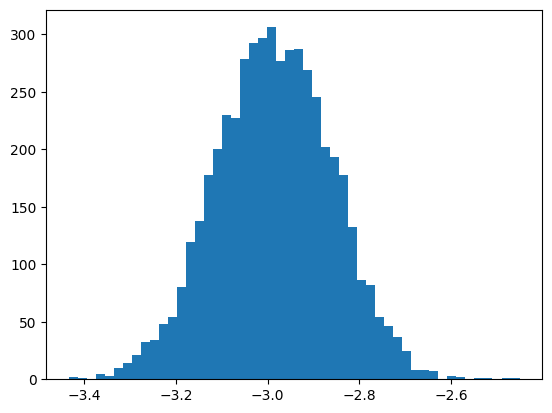

In [18]:
# check a single histogram to see its shape
_ = plt.hist(data_hist[:,8], bins=50)  # arguments are passed to np.histogram

plt.show()

### Plot results

In [19]:
err_bars

array([0.35316518, 0.35200451, 0.35509225, 0.35414452, 0.35588317,
       0.35474668, 0.35430235, 0.35505689, 0.35558451, 0.35492617,
       0.35376629, 0.35744576, 0.35801235, 0.35496243, 0.35743387,
       0.35681449, 0.35914344, 0.35697054, 0.35757296, 0.35618317])

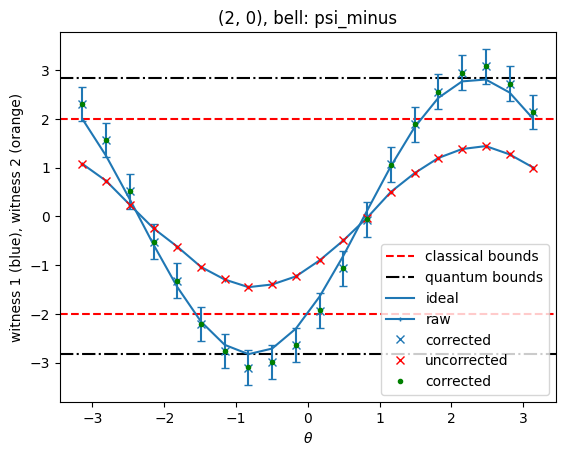

In [20]:
fname = f"chsh_{CONTROL_QUBIT}_{TARGET_QUBIT}_{BELL_STATE}_nshots{NUM_SHOTS}_jobid{result_id}.png"
savefig = False

fig, ax = plt.subplots()
ax.axhline(2, color="red", linestyle="--", label="classical bounds")
ax.axhline(-2, color="red", linestyle="--")
ax.axhline(2 * np.sqrt(2), color="k", linestyle="-.", label="quantum bounds")
ax.axhline(-2 * np.sqrt(2), color="k", linestyle="-.")

ax.plot(THETA_VALUES, w1_ideal, label="ideal")
# ax.plot(THETA_VALUES, w2_ideal)

ax.plot(THETA_VALUES, w1_raw, "+-", ms=3, c="C0", label="raw")
# ax.plot(THETA_VALUES, w2_raw, "x", ms=3, c="C1")

ax.plot(THETA_VALUES, w1_corrected, "x", c="C0", label="corrected")
ax.errorbar(THETA_VALUES, w1_corrected, err_bars, capsize=3, c="C0", ls="none")  # "x--",
ax.plot(THETA_VALUES, np.mean(data_hist_unc, axis=0), "x", c="red", label="uncorrected")

# ax.errorbar(THETA_VALUES, w1_raw, err_bars_unc, capsize=3, c="C0", ls="none")  # "x--",
ax.plot(THETA_VALUES, np.mean(data_hist, axis=0), ".", c="green", label="corrected")


# ax.plot(THETA_VALUES, w2_corrected, ".", c="C1")
ax.legend()

ax.set_xlabel("$\\theta$")
ax.set_ylabel("witness 1 (blue), witness 2 (orange)")

ax.set_title(f"({CONTROL_QUBIT}, {TARGET_QUBIT}), bell: {BELL_STATE}")
if savefig:
    fig.savefig(fname, bbox_inches="tight")